# Aussagekraft der Ratio über Stocks und Volumen

In diesem Notebook soll die Raito Advancing/Declining Volume sowie Advancing/Declining Stocks untersucht werden.

1. Bibliotheken laden

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

2. Daten laden

In [2]:
boerse = 'NASDAQ'

In [3]:
advancing_stocks = pd.read_csv(f"{boerse} Advancing Stocks.csv", parse_dates=["time"])
advancing_stocks = advancing_stocks[advancing_stocks["time"] >= pd.Timestamp("2006-12-31")]
advancing_stocks.info()
advancing_volume = pd.read_csv(f"{boerse} Advancing Volume.csv", parse_dates=["time"])
advancing_volume = advancing_volume[advancing_volume["time"] >= pd.Timestamp("2006-12-31")]
advancing_volume.info()
declining_stocks = pd.read_csv(f"{boerse} Declining Stocks.csv", parse_dates=["time"])
declining_stocks = declining_stocks[declining_stocks["time"] >= pd.Timestamp("2006-12-31")]
declining_stocks.info()
declining_volume = pd.read_csv(f"{boerse} Declining Volume.csv", parse_dates=["time"])
declining_volume = declining_volume[declining_volume["time"] >= pd.Timestamp("2006-12-31")]
declining_volume.info()

# NASDAQ Composite, um die Ratio dann mit dem Markt zu vergleichen
raw = yf.download("^IXIC", start="2007-01-01", interval="1d", auto_adjust=True, progress=False, multi_level_index=False)

<class 'pandas.DataFrame'>
RangeIndex: 4745 entries, 0 to 4744
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    4745 non-null   datetime64[us]
 1   open    4745 non-null   int64         
 2   high    4745 non-null   int64         
 3   low     4745 non-null   int64         
 4   close   4745 non-null   int64         
 5   EMA     4546 non-null   float64       
 6   EMA.1   4726 non-null   float64       
 7   EMA.2   4696 non-null   float64       
 8   EMA.3   4646 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(4)
memory usage: 333.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 4738 entries, 0 to 4737
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   time    4738 non-null   datetime64[us]
 1   open    4738 non-null   float64       
 2   high    4738 non-null   float64       
 3   low     4738 non-null   float6

In [4]:
df = advancing_stocks[['time', 'close']]
df = df.rename(columns={'close' : 'advancing_stocks'})

df["time"] = pd.to_datetime(df["time"])
advancing_volume["time"] = pd.to_datetime(advancing_volume["time"])
declining_stocks["time"] = pd.to_datetime(declining_stocks["time"])
declining_volume["time"] = pd.to_datetime(declining_volume["time"])

df = df.set_index("time")

df = (df
    .join(advancing_volume.set_index("time")[["close"]].rename(columns= {"close": "advancing_volume"}),how = "left")
    .join(declining_stocks.set_index("time")[["close"]].rename(columns= {"close": "declining_stocks"}),how = "left")
    .join(declining_volume.set_index("time")[["close"]].rename(columns= {"close": "declining_volume"}),how = "left")
)
print(df.tail())

            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2026-08-04              2195           7106.99               847   
2026-08-05              1240           3782.56              1797   
2026-08-06              1389           4141.86              1639   
2026-08-07              1894           4842.99              1143   
2026-08-10              1206           3294.95              1843   

            declining_volume  
time                          
2026-08-04           1414.77  
2026-08-05           4399.61  
2026-08-06           3862.86  
2026-08-07           2227.56  
2026-08-10           3412.36  


In [5]:
print (df[df['advancing_volume'] > 150000])
print (df[df['declining_volume'] > 150000])

            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2010-05-12              2189          203055.5               524   

            declining_volume  
time                          
2010-05-12          22786.02  
            advancing_stocks  advancing_volume  declining_stocks  \
time                                                               
2010-05-13               945          49907.64              1761   

            declining_volume  
time                          
2010-05-13          175156.7  


In [6]:
# dieser Ausreißer wird aus der Analyse herausgenommen, weil es sich wohl um ein einmaliges Ereignis handelt, durch das man nichts für die Zukunft sagen kann
df = df[(df['advancing_volume'] < 150000) & (df['declining_volume'] < 150000)]

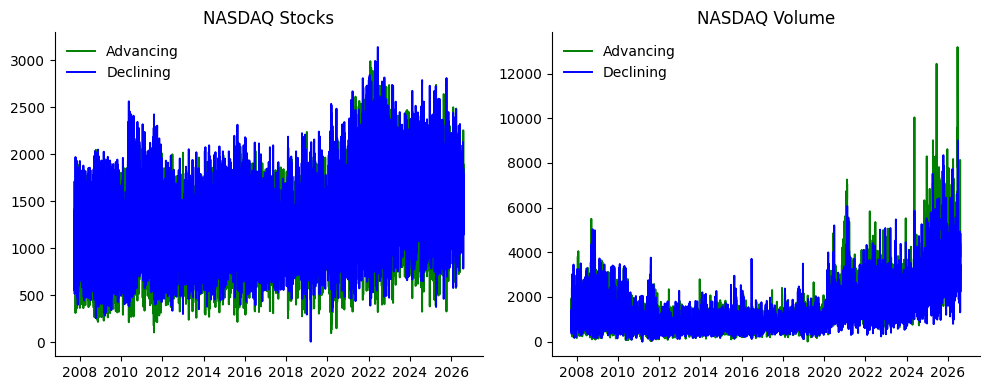

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(df.index, df["advancing_stocks"], color='green', linewidth=1.4, label="Advancing")
ax[0].plot(df.index, df["declining_stocks"], color='blue', linewidth=1.4, label="Declining")

ax[1].plot(df.index, df["advancing_volume"], color='green', linewidth=1.4, label="Advancing")
ax[1].plot(df.index, df["declining_volume"], color='blue', linewidth=1.4, label="Declining")

ax[0].set_title(f"{boerse} Stocks")
ax[0].legend(frameon=False, loc="upper left")
ax[0].spines[["top", "right"]].set_visible(False)

ax[1].set_title(f"{boerse} Volume")
ax[1].legend(frameon=False, loc="upper left")
ax[1].spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()

3. Ratio berechnen

In [8]:
df["volume_ratio"] = (df["declining_volume"] / (df["advancing_volume"] + df["declining_volume"]))*100
df["stocks_ratio"] = (df["declining_stocks"] / (df["advancing_stocks"] + df["declining_stocks"]))*100

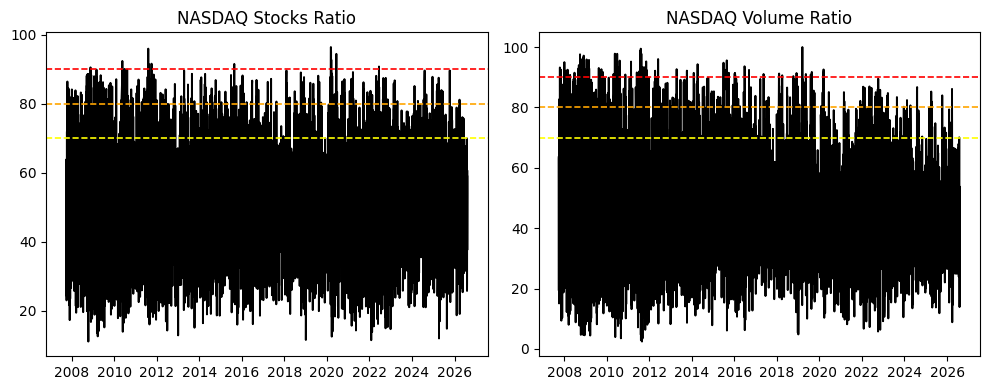

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(df.index, df["stocks_ratio"], color='black', linewidth=1.4, label="Ratio")
ax[0].axhline(90, color="red", linestyle="--", linewidth=1.2, label="90 %")
ax[0].axhline(80, color="orange", linestyle="--", linewidth=1.2, label="80 %")
ax[0].axhline(70, color="yellow", linestyle="--", linewidth=1.2, label="70 %")

ax[1].plot(df.index, df["volume_ratio"], color='black', linewidth=1.4, label="Ratio")
ax[1].axhline(90, color="red", linestyle="--", linewidth=1.2, label="90 %")
ax[1].axhline(80, color="orange", linestyle="--", linewidth=1.2, label="80 %")
ax[1].axhline(70, color="yellow", linestyle="--", linewidth=1.2, label="70 %")

ax[0].set_title(f"{boerse} Stocks Ratio")

ax[1].set_title(f"{boerse} Volume Ratio")

fig.tight_layout()
plt.show()

4. Untersuchen, was nach den Extremwerten passiert

In [10]:
HORIZONS = [30, 60, 90]

def forward_return(close: pd.Series, horizon: int) -> pd.Series:
    '''Rendite von t bis t+horizon (in Handelstagen), bezogen auf Close.'''
    return close.shift(-horizon) / close - 1


def forward_max_drawdown(close: pd.Series, horizon: int) -> pd.Series:
    '''Maximaler Drawdown ab dem laufenden Hoechststand innerhalb [t, t+horizon].

    Fuer jeden Zeitpunkt t wird das Fenster der naechsten `horizon` Handelstage
    betrachtet und der groesste prozentuale Rueckgang vom bis dahin erreichten
    Hoechststand innerhalb dieses Fensters berechnet (immer <= 0).
    '''
    values = close.values
    n = len(values)
    out = np.full(n, np.nan)
    for i in range(n - horizon):
        window = values[i : i + horizon + 1]
        running_max = np.maximum.accumulate(window)
        drawdowns = window / running_max - 1
        out[i] = drawdowns.min()
    return pd.Series(out, index=close.index)


# Zielgroessen fuer alle Horizonte berechnen und an df anhaengen
for h in HORIZONS:
    raw[f"fwd_return_{h}d"] = forward_return(raw["Close"], h)
    raw[f"fwd_mdd_{h}d"] = forward_max_drawdown(raw["Close"], h)

print("Zielgroessen berechnet fuer Horizonte:", HORIZONS)
raw.filter(like="fwd_").describe()

Zielgroessen berechnet fuer Horizonte: [30, 60, 90]


,fwd_return_30d,fwd_mdd_30d,fwd_return_60d,fwd_mdd_60d,fwd_return_90d,fwd_mdd_90d
count,4903.000000,4903.000000,4873.000000,4873.000000,4843.000000,4843.000000
mean,0.016779,-0.060993,0.033960,-0.089040,0.050890,-0.109708
std,0.066812,0.048376,0.092795,0.064743,0.113123,0.074866
min,-0.316021,-0.337746,-0.447579,-0.454263,-0.423980,-0.463612
25%,-0.017241,-0.078302,-0.011010,-0.109247,-0.002886,-0.131473
50%,0.024465,-0.045748,0.044900,-0.072976,0.063691,-0.087038
75%,0.056475,-0.028610,0.085873,-0.043207,0.115589,-0.057987
max,0.295758,-0.007704,0.451259,-0.014042,0.543262,-0.018665


In [11]:
# Füge die Rendite und den Max Drawdown zum allgemeinen df hinzu
raw.index = pd.to_datetime(raw.index)

df = df.join(raw[["fwd_return_30d", "fwd_mdd_30d", "fwd_return_60d", "fwd_mdd_60d", "fwd_return_90d", "fwd_mdd_90d"]],how = "left")

print(df.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 4736 entries, 2007-09-28 to 2026-08-10
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   advancing_stocks  4736 non-null   int64  
 1   advancing_volume  4736 non-null   float64
 2   declining_stocks  4736 non-null   int64  
 3   declining_volume  4736 non-null   float64
 4   volume_ratio      4736 non-null   float64
 5   stocks_ratio      4736 non-null   float64
 6   fwd_return_30d    4707 non-null   float64
 7   fwd_mdd_30d       4707 non-null   float64
 8   fwd_return_60d    4677 non-null   float64
 9   fwd_mdd_60d       4677 non-null   float64
 10  fwd_return_90d    4647 non-null   float64
 11  fwd_mdd_90d       4647 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 481.0 KB
None


In [12]:
# Aufteilung in verschiedene Regime (über 90%, 80%, 70%)
stock_over_90 = df[df["stocks_ratio"] >= 90]
print("Stock über 90%:")
print(stock_over_90[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
stock_over_80 = df[df["stocks_ratio"] >= 80]
print("Stock über 80%:")
print(stock_over_80[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
stock_over_70 = df[df["stocks_ratio"] >= 70]
print("Stock über 70%:")
print(stock_over_70[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()

volume_over_90 = df[df["volume_ratio"] >= 90]
print("Volumen über 90%:")
print(volume_over_90[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
volume_over_80 = df[df["volume_ratio"] >= 80]
print("Volumen über 80%:")
print(volume_over_80[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())
print()
volume_over_70 = df[df["volume_ratio"] >= 70]
print("Volumen über 70%:")
print(volume_over_70[["volume_ratio", "stocks_ratio", "fwd_return_30d", "fwd_mdd_30d"]].describe())

Stock über 90%:
       volume_ratio  stocks_ratio  fwd_return_30d  fwd_mdd_30d
count     13.000000     13.000000       13.000000    13.000000
mean      93.865108     92.739281        0.090254    -0.081231
std        4.939988      2.096679        0.083357     0.038368
min       85.096542     90.048273       -0.050916    -0.177797
25%       91.587064     91.444489        0.034400    -0.089543
50%       95.582646     92.360360        0.091696    -0.078904
75%       97.780419     94.414894        0.137591    -0.049871
max       99.460689     96.389206        0.246668    -0.037513

Stock über 80%:
       volume_ratio  stocks_ratio  fwd_return_30d  fwd_mdd_30d
count    255.000000    255.000000      255.000000   255.000000
mean      85.640118     84.578083        0.023272    -0.081680
std        7.981634      3.304684        0.091253     0.065316
min       39.462463     80.000000       -0.309192    -0.337746
25%       81.621399     81.762905       -0.025381    -0.105148
50%       86.580447   

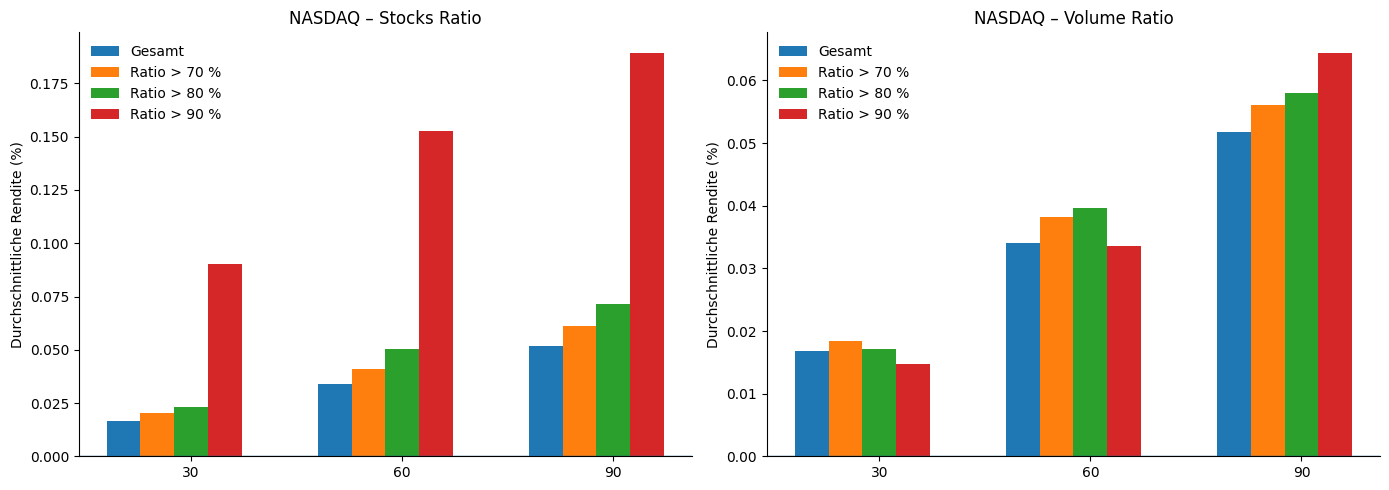

In [13]:
x = np.arange(len(HORIZONS)) + 1
width = 0.16

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Stocks Ratio
# -------------------------

ax[0].bar(x - 2*width, df[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Gesamt")
ax[0].bar(x - width, stock_over_70[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[0].bar(x,         stock_over_80[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[0].bar(x + width, stock_over_90[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[0].axhline(0, linewidth=1)

ax[0].set_xticks(x)
ax[0].set_xticklabels(HORIZONS)

ax[0].set_ylabel("Durchschnittliche Rendite (%)")
ax[0].set_title("NASDAQ – Stocks Ratio")
ax[0].legend(frameon=False)

ax[0].spines[["top", "right"]].set_visible(False)


# -------------------------
# Volume Ratio
# -------------------------

ax[1].bar(x - 2*width, df[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Gesamt")
ax[1].bar(x - width, volume_over_70[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[1].bar(x,         volume_over_80[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[1].bar(x + width, volume_over_90[["fwd_return_30d", "fwd_return_60d", "fwd_return_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[1].axhline(0, linewidth=1)

ax[1].set_xticks(x)
ax[1].set_xticklabels(HORIZONS)

ax[1].set_ylabel("Durchschnittliche Rendite (%)")
ax[1].set_title("NASDAQ – Volume Ratio")
ax[1].legend(frameon=False)

ax[1].spines[["top", "right"]].set_visible(False)


fig.tight_layout()
plt.show()

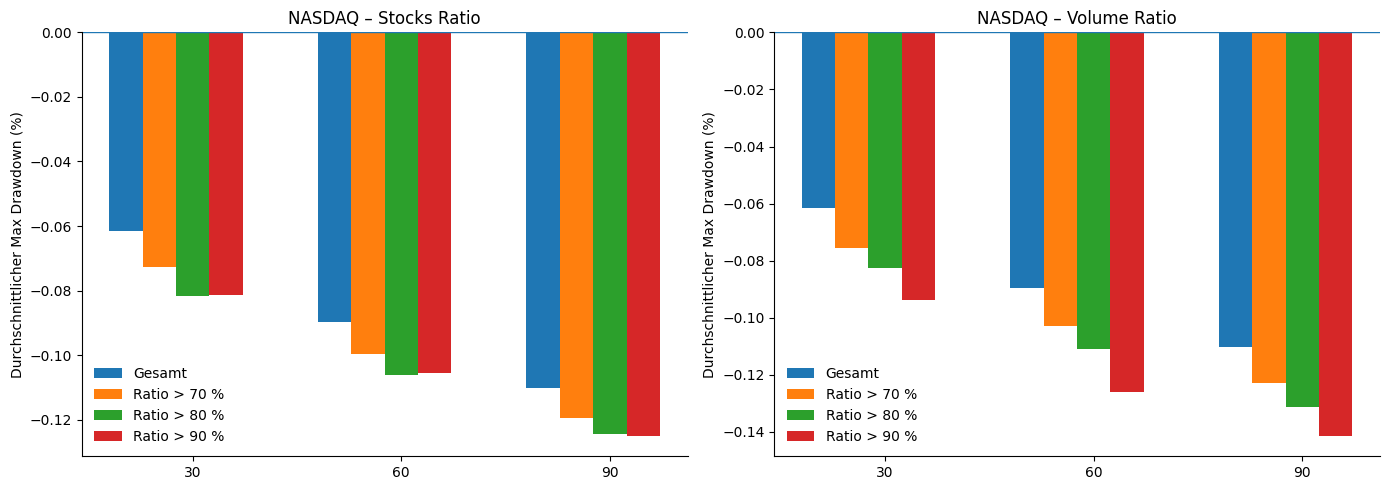

In [14]:
x = np.arange(len(HORIZONS))
width = 0.16

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Stocks Ratio
# -------------------------

ax[0].bar(x - 2*width, df[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Gesamt")
ax[0].bar(x - width, stock_over_70[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[0].bar(x,         stock_over_80[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[0].bar(x + width, stock_over_90[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[0].axhline(0, linewidth=1)

ax[0].set_xticks(x)
ax[0].set_xticklabels(HORIZONS)

ax[0].set_ylabel("Durchschnittlicher Max Drawdown (%)")
ax[0].set_title("NASDAQ – Stocks Ratio")
ax[0].legend(frameon=False)

ax[0].spines[["top", "right"]].set_visible(False)


# -------------------------
# Volume Ratio
# -------------------------

ax[1].bar(x - 2*width, df[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Gesamt")
ax[1].bar(x - width, volume_over_70[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 70 %")
ax[1].bar(x,         volume_over_80[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 80 %")
ax[1].bar(x + width, volume_over_90[["fwd_mdd_30d", "fwd_mdd_60d", "fwd_mdd_90d"]].mean().to_list(), width, label="Ratio > 90 %")

ax[1].axhline(0, linewidth=1)

ax[1].set_xticks(x)
ax[1].set_xticklabels(HORIZONS)

ax[1].set_ylabel("Durchschnittlicher Max Drawdown (%)")
ax[1].set_title("NASDAQ – Volume Ratio")
ax[1].legend(frameon=False)

ax[1].spines[["top", "right"]].set_visible(False)


fig.tight_layout()
plt.show()